날짜별 "시청 수"와 "평균 duration"

C:\Users\user\AppData\Local\Temp\ipykernel_11204\3610720196.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(date_labels, rotation=45)


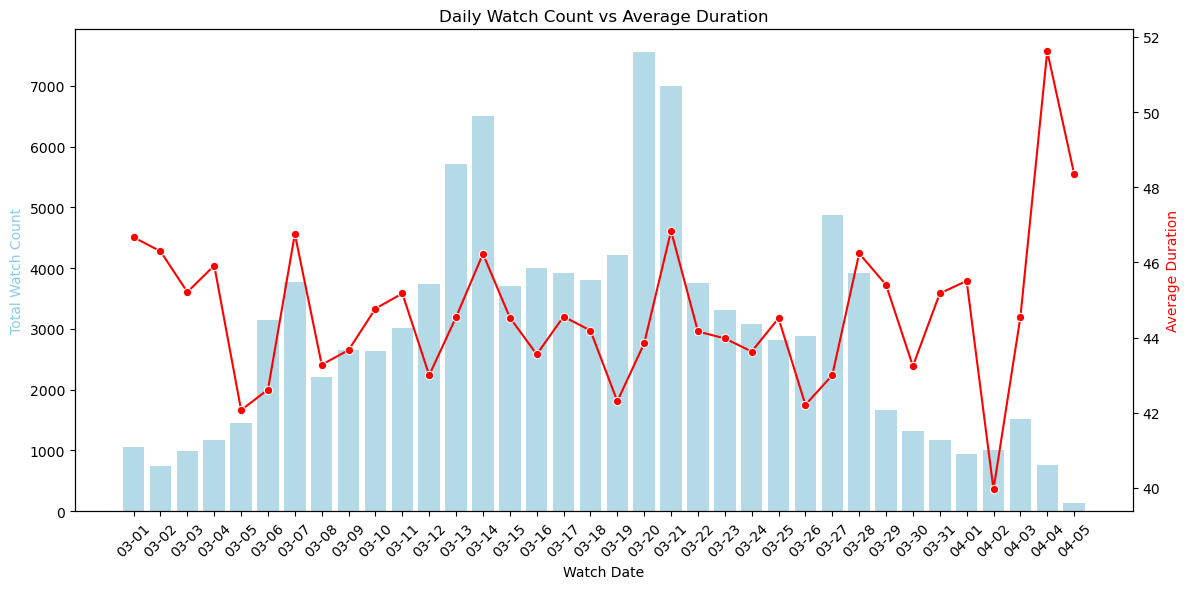

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("C:/Users/user/Desktop/기업 연계 데이터/View_History.csv")
df['WATCH_DAY'] = pd.to_datetime(df['WATCH_DAY'], format='%Y%m%d')

daily_stats = df.groupby('WATCH_DAY').agg({
    'USER_ID': 'count',
    'DURATION': 'mean'
}).reset_index()
daily_stats.columns = ['WATCH_DAY', 'total_count', 'duration_mean']

fig, ax1 = plt.subplots(figsize=(12, 6))

# 시청 건수
sns.barplot(data=daily_stats, x='WATCH_DAY', y='total_count', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('Watch Date')
ax1.set_ylabel('Total Watch Count', color='skyblue')
ax1.set_title('Daily Watch Count vs Average Duration')

# 날짜 라벨 정리
date_labels = daily_stats['WATCH_DAY'].dt.strftime('%m-%d')
ax1.set_xticklabels(date_labels, rotation=45)

# 평균 시청 시간 - 오른쪽 보조축
ax2 = ax1.twinx()
sns.lineplot(data=daily_stats, x=range(len(daily_stats)), y='duration_mean', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Duration', color='red')

plt.tight_layout()
plt.show()

 날짜별 "총 고유id 수"와 "총 시청 수"

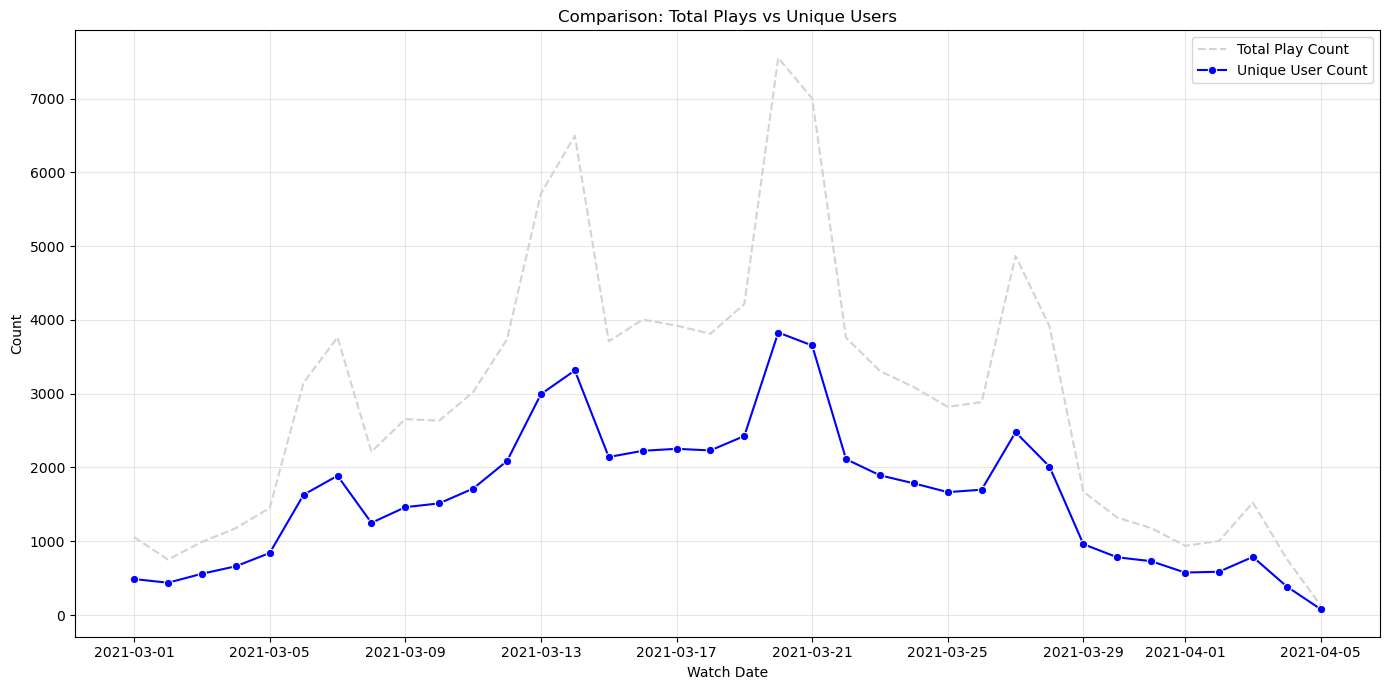

In [11]:
# 2. 날짜별 집계 (재생 건수 vs 고유 유저 수)
daily_stats = df.groupby('WATCH_DAY').agg({
    'USER_ID': ['count', 'nunique']
}).reset_index()


daily_stats.columns = ['WATCH_DAY', 'total_plays', 'unique_users']

# 시각화
plt.figure(figsize=(14, 7))

# Total Plays
sns.lineplot(data=daily_stats, x='WATCH_DAY', y='total_plays',
             label='Total Play Count', color='lightgray', linestyle='--')

# Unique Users
sns.lineplot(data=daily_stats, x='WATCH_DAY', y='unique_users',
             label='Unique User Count', color='blue', marker='o')

plt.title('Comparison: Total Plays vs Unique Users')
plt.xlabel('Watch Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

요일별 "평균 고유id 수"와 "평균 시청 수"

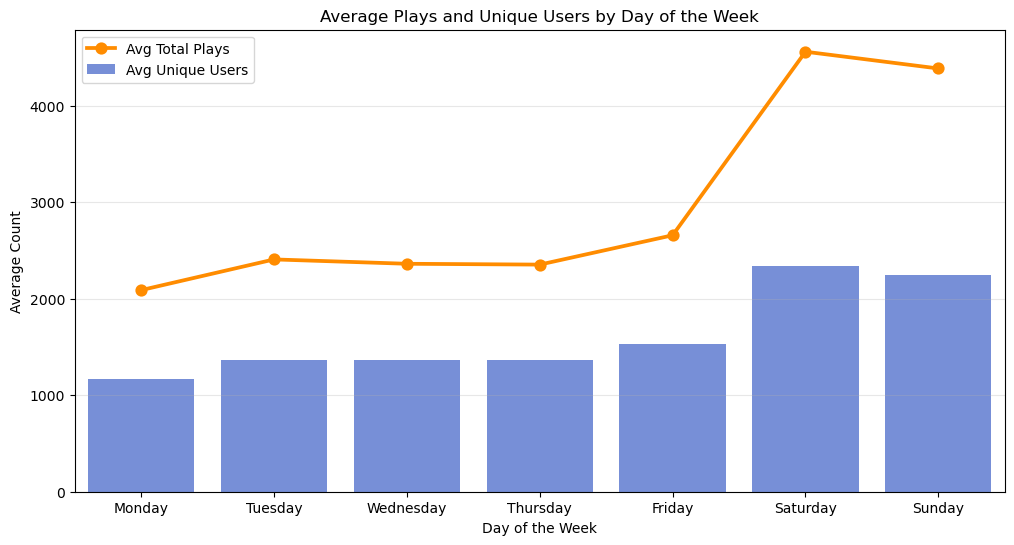

In [12]:
# 요일 정보 추출 및 순서 정렬
# 월요일 ~ 일요일 순서로 정렬
df['day_of_week'] = df['WATCH_DAY'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_stats = df.groupby(['WATCH_DAY', 'day_of_week']).agg({
    'USER_ID': ['count', 'nunique']
}).reset_index()
daily_stats.columns = ['WATCH_DAY', 'day_of_week', 'total_plays', 'unique_users']

# 요일별 평균값 계산
dow_stats = daily_stats.groupby('day_of_week').agg({
    'total_plays': 'mean',
    'unique_users': 'mean'
}).reindex(day_order).reset_index()

# 시각화
plt.figure(figsize=(12, 6))

# 고유 유저 수
sns.barplot(data=dow_stats, x='day_of_week', y='unique_users', color='royalblue', alpha=0.8, label='Avg Unique Users')

# 전체 재생 건수
sns.pointplot(data=dow_stats, x='day_of_week', y='total_plays', color='darkorange', label='Avg Total Plays')

plt.title('Average Plays and Unique Users by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

날짜별 "총 duration"과 "평균 duration"

C:\Users\user\AppData\Local\Temp\ipykernel_11204\4084317640.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(date_labels, rotation=45)


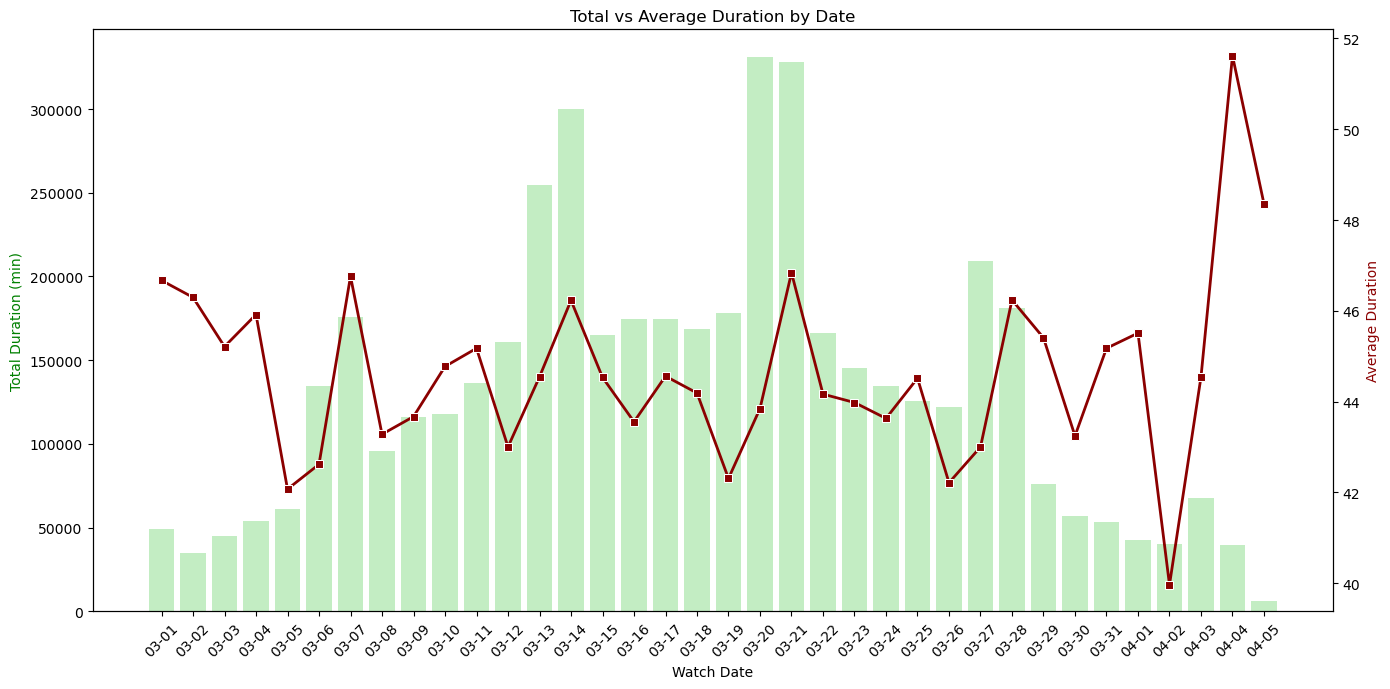

In [14]:
# 날짜별 시청 시간 집계
duration_stats = df.groupby('WATCH_DAY')['DURATION'].agg(['sum', 'mean']).reset_index()
duration_stats.columns = ['WATCH_DAY', 'total_duration', 'avg_duration']

# 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))

# 총 시청 시간
sns.barplot(data=duration_stats, x='WATCH_DAY', y='total_duration', ax=ax1, color='lightgreen', alpha=0.6)
ax1.set_ylabel('Total Duration (min)', color='green')
ax1.set_xlabel('Watch Date')
ax1.set_title('Total vs Average Duration by Date')

date_labels = duration_stats['WATCH_DAY'].dt.strftime('%m-%d')
ax1.set_xticklabels(date_labels, rotation=45)

# 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(data=duration_stats, x=range(len(duration_stats)), y='avg_duration', ax=ax2, color='darkred', marker='s', linewidth=2)
ax2.set_ylabel('Average Duration', color='darkred')

plt.tight_layout()
plt.show()

요일별 "총 duration"과 "평균 duration"

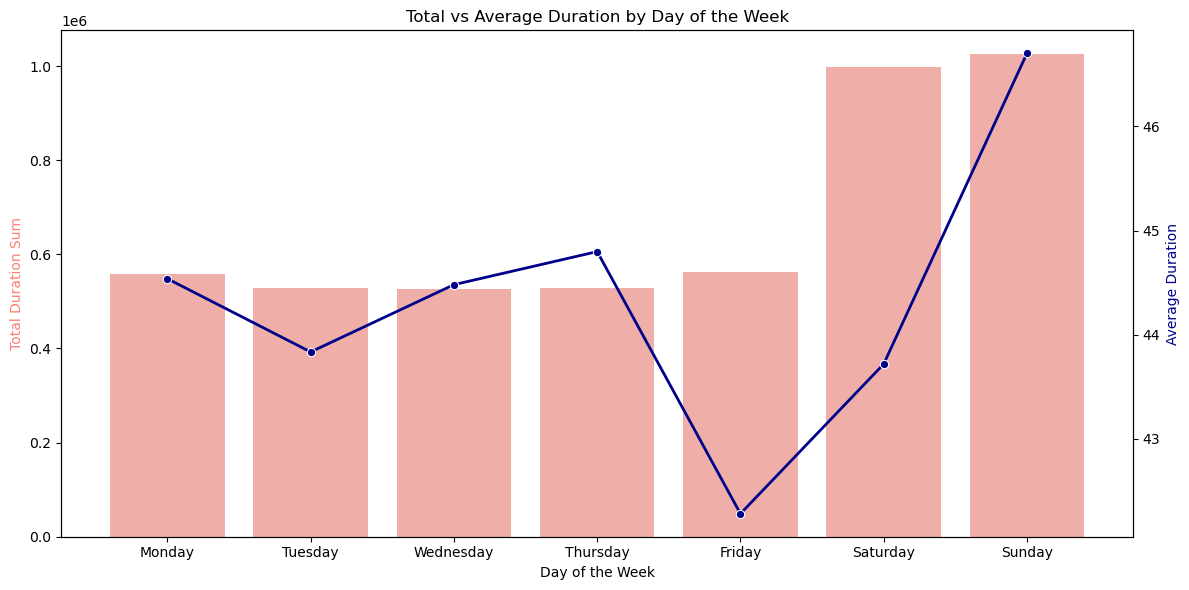

In [15]:
df['day_of_week'] = df['WATCH_DAY'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 요일별 Duration 집계
dow_duration_stats = df.groupby('day_of_week')['DURATION'].agg(['sum', 'mean']).reindex(day_order).reset_index()
dow_duration_stats.columns = ['day_of_week', 'total_duration', 'avg_duration']

# 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# 요일별 총 시청 시간 합계
sns.barplot(data=dow_duration_stats, x='day_of_week', y='total_duration', ax=ax1, color='salmon', alpha=0.7)
ax1.set_ylabel('Total Duration Sum', color='salmon')
ax1.set_xlabel('Day of the Week')
ax1.set_title('Total vs Average Duration by Day of the Week')

# 요일별 평균 시청 시간
ax2 = ax1.twinx()
sns.lineplot(data=dow_duration_stats, x=range(len(dow_duration_stats)), y='avg_duration', ax=ax2, color='darkblue', marker='o', linewidth=2)
ax2.set_ylabel('Average Duration', color='darkblue')

plt.tight_layout()
plt.show()

하루에 몇 번째 재생했는지 분포 파악

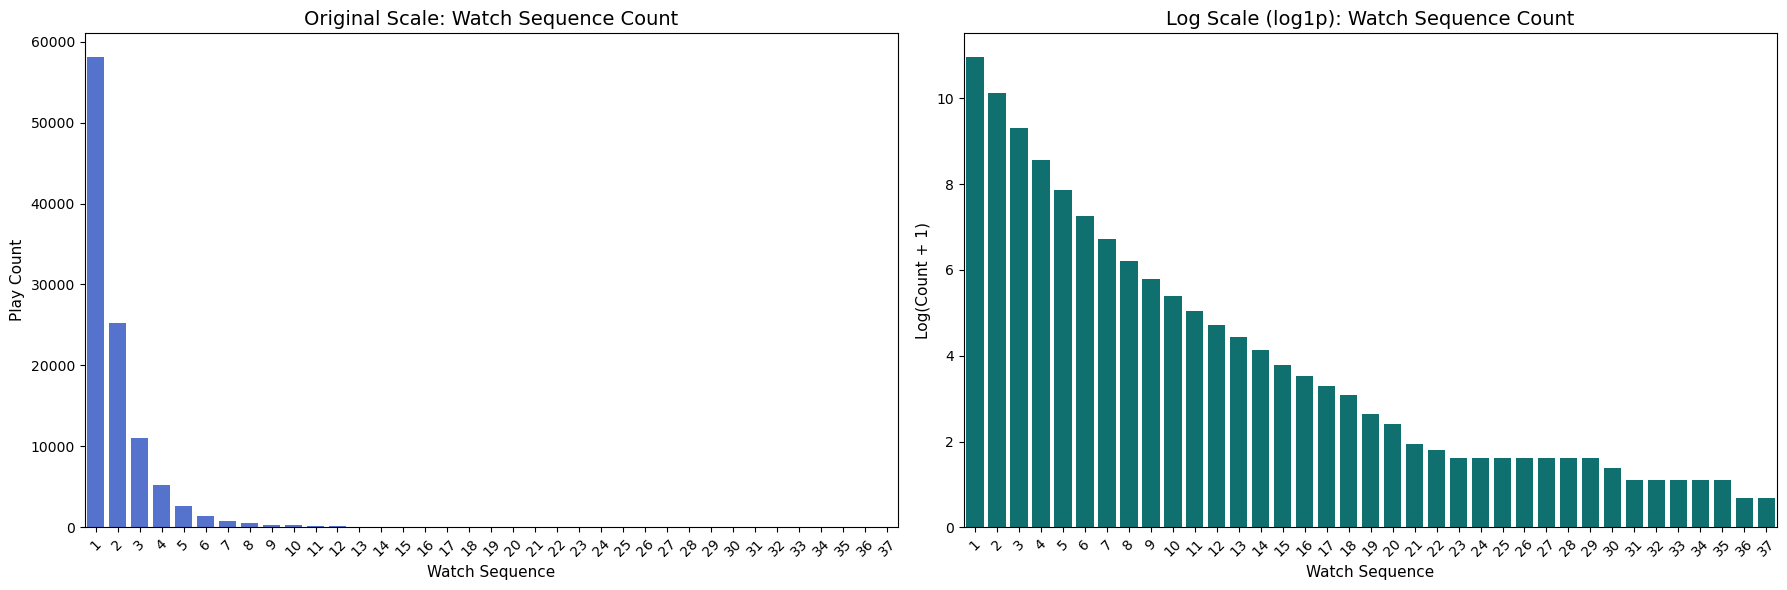

In [18]:
# WATCH_SEQ별 빈도수 계산
seq_counts = df['WATCH_SEQ'].value_counts().sort_index().reset_index()
seq_counts.columns = ['WATCH_SEQ', 'count']
seq_counts['log_count'] = np.log1p(seq_counts['count'])

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 왼쪽: 원본 스케일
sns.barplot(data=seq_counts, x=seq_counts['WATCH_SEQ'].astype(str), y='count', ax=ax1, color='royalblue')
ax1.set_title('Original Scale: Watch Sequence Count', fontsize=14)
ax1.set_xlabel('Watch Sequence', fontsize=11)
ax1.set_ylabel('Play Count', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# 오른쪽: 로그 스케일
sns.barplot(data=seq_counts, x=seq_counts['WATCH_SEQ'].astype(str), y='log_count', ax=ax2, color='teal')
ax2.set_title('Log Scale (log1p): Watch Sequence Count', fontsize=14)
ax2.set_xlabel('Watch Sequence', fontsize=11)
ax2.set_ylabel('Log(Count + 1)', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

날짜별 "총 watch_seq"와 "평균 watch_seq"

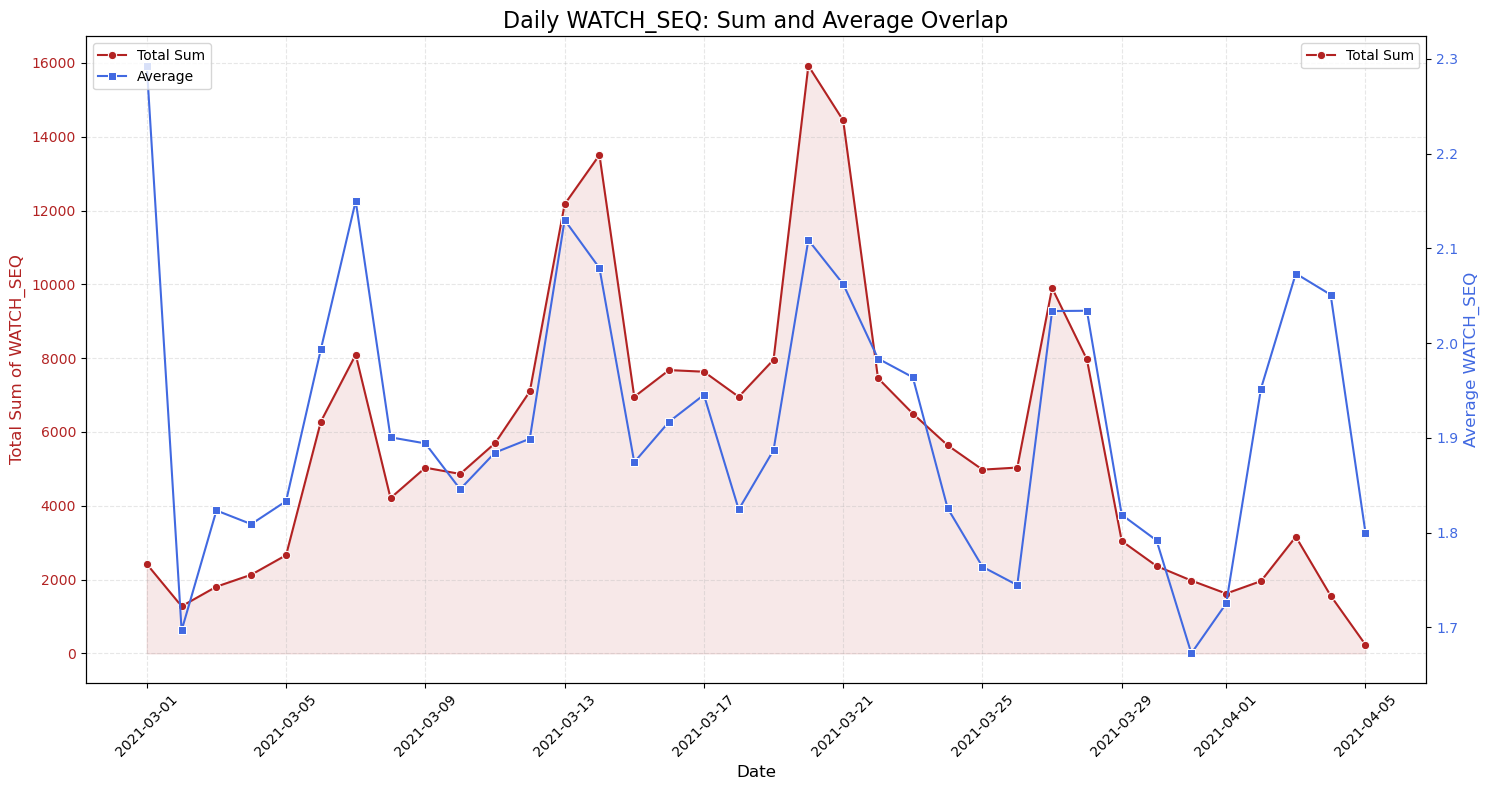

In [19]:
# 날짜별 WATCH_SEQ의 합계와 평균
daily_stats = df.groupby('WATCH_DAY')['WATCH_SEQ'].agg(['sum', 'mean']).reset_index()

# 시각화
fig, ax1 = plt.subplots(figsize=(15, 8))

# 왼쪽 축: WATCH_SEQ 총합
sns.lineplot(data=daily_stats, x='WATCH_DAY', y='sum', ax=ax1, color='firebrick', marker='o', label='Total Sum')
ax1.fill_between(daily_stats['WATCH_DAY'], daily_stats['sum'], color='firebrick', alpha=0.1) # 가독성을 위한 면적 채우기
ax1.set_ylabel('Total Sum of WATCH_SEQ', fontsize=12, color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')

# 오른쪽 축: WATCH_SEQ 평균
ax2 = ax1.twinx()
sns.lineplot(data=daily_stats, x='WATCH_DAY', y='mean', ax=ax2, color='royalblue', marker='s', label='Average')
ax2.set_ylabel('Average WATCH_SEQ', fontsize=12, color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')


plt.title('Daily WATCH_SEQ: Sum and Average Overlap', fontsize=16)
ax1.set_xlabel('Date', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

날짜별 "총 고유 영화 수"와 요일별 "평균 고유 영화 수"

C:\Users\user\AppData\Local\Temp\ipykernel_11204\4192989609.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_avg_unique, x='day_name', y='MOVIE_ID', ax=ax2, palette='Oranges')


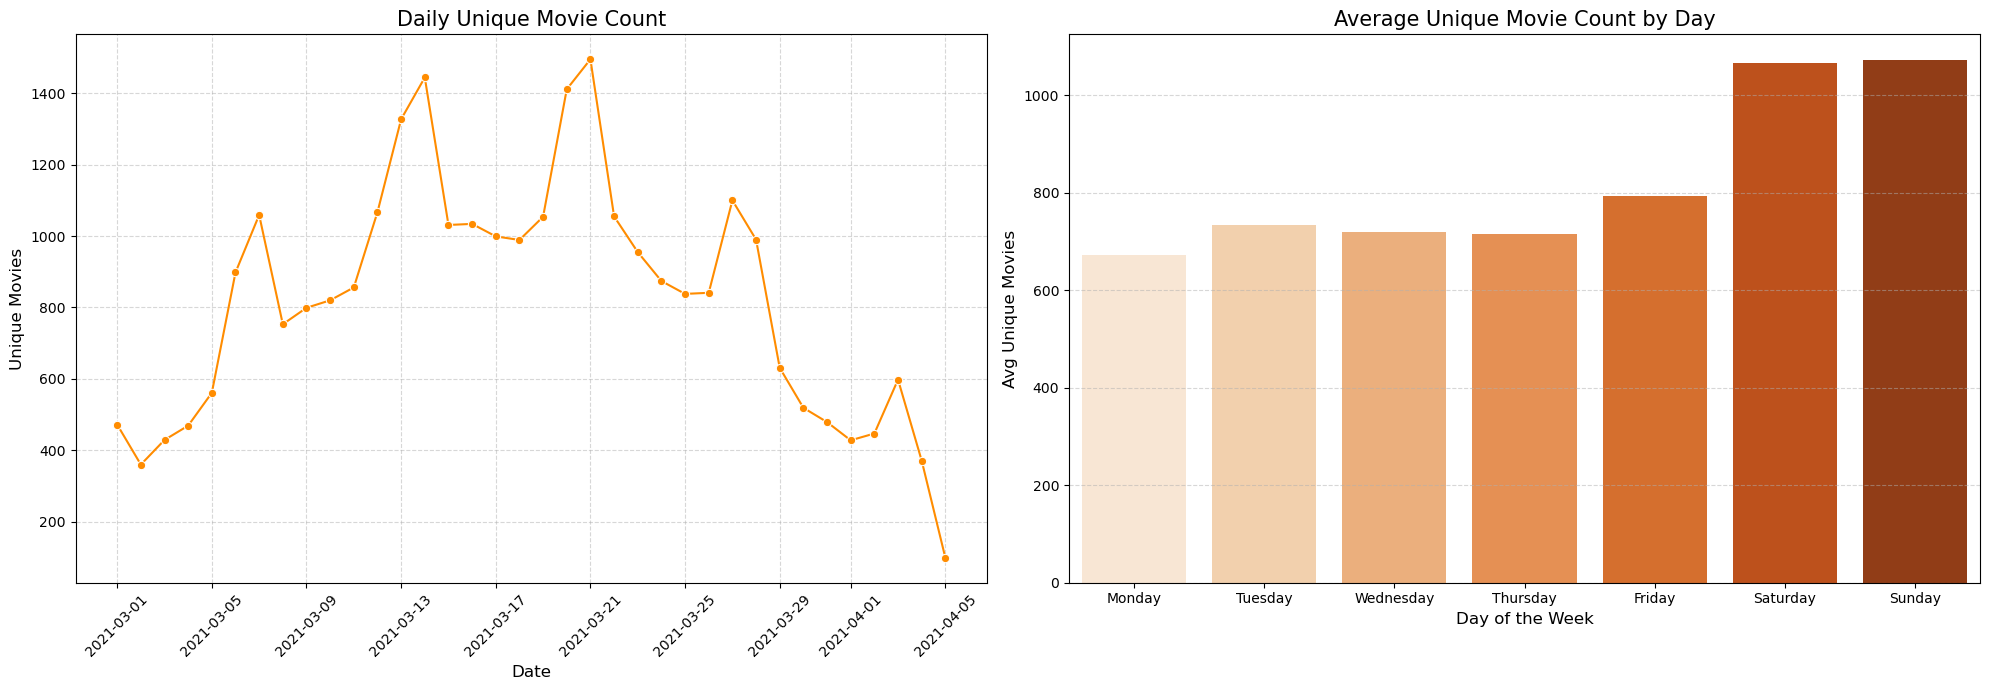

In [20]:
df['day_name'] = df['WATCH_DAY'].dt.day_name()


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 날짜별 고유 영화 수
daily_unique = df.groupby('WATCH_DAY')['MOVIE_ID'].nunique().reset_index()

# 요일별 평균 고유 영화 수
weekly_unique = df.groupby(['WATCH_DAY', 'day_name'])['MOVIE_ID'].nunique().reset_index()
weekly_avg_unique = weekly_unique.groupby('day_name')['MOVIE_ID'].mean().reindex(day_order).reset_index()

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# 왼쪽: 날짜별 고유 영화 수
sns.lineplot(data=daily_unique, x='WATCH_DAY', y='MOVIE_ID', ax=ax1, marker='o', color='darkorange')
ax1.set_title('Daily Unique Movie Count', fontsize=15)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Unique Movies', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.5)

# 오른쪽: 요일별 고유 영화 수
sns.barplot(data=weekly_avg_unique, x='day_name', y='MOVIE_ID', ax=ax2, palette='Oranges')
ax2.set_title('Average Unique Movie Count by Day', fontsize=15)
ax2.set_xlabel('Day of the Week', fontsize=12)
ax2.set_ylabel('Avg Unique Movies', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

결측치 확인

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
view_history = pd.read_csv("C:/Users/user/Desktop/기업 연계 데이터/View_History.csv")

# 한글 출력 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 컬럼 목록 출력
print("View_History 컬럼 목록")
for idx, col in enumerate(view_history.columns, start=1):
    print(f"{idx}. {col}")

print(f"\n전체 행 수: {len(view_history):,}")
print(f"전체 컬럼 수: {view_history.shape[1]}")

# 컬럼별 결측치 요약
missing_summary = pd.DataFrame({
    "컬럼명": view_history.columns,
    "데이터타입": view_history.dtypes.astype(str).values,
    "결측치 수": view_history.isna().sum().values,
    "결측치 비율(%)": (view_history.isna().mean() * 100).round(2).values,
    "고유값 수": view_history.nunique(dropna=True).values
})

missing_summary = missing_summary.sort_values(
    by=["결측치 수", "컬럼명"],
    ascending=[False, True]
).reset_index(drop=True)

display(missing_summary)


View_History 컬럼 목록
1. USER_ID
2. MOVIE_ID
3. DURATION
4. WATCH_DAY
5. WATCH_SEQ

전체 행 수: 106,205
전체 컬럼 수: 5


,컬럼명,데이터타입,결측치 수,결측치 비율(%),고유값 수
0,DURATION,int64,0,0.0,200
1,MOVIE_ID,int64,0,0.0,5196
2,USER_ID,int64,0,0.0,14892
3,WATCH_DAY,int64,0,0.0,36
4,WATCH_SEQ,int64,0,0.0,37


이상치 확인

IQR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
view_history = pd.read_csv("C:/Users/user/Desktop/기업 연계 데이터/View_History.csv")

# 한글 출력 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 확인할 수치형 컬럼 선택
numeric_cols = ["DURATION", "WATCH_SEQ"]

# 이상치 요약 결과 저장용
outlier_result = []

for col in numeric_cols:
    q1 = view_history[col].quantile(0.25)
    q3 = view_history[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (view_history[col] < lower_bound) | (view_history[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(view_history)) * 100, 2)

    outlier_result.append({
        "컬럼명": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "하한값": lower_bound,
        "상한값": upper_bound,
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": view_history[col].min(),
        "최댓값": view_history[col].max()
    })

# 결과 테이블
outlier_summary = pd.DataFrame(outlier_result)
display(outlier_summary)

,컬럼명,Q1,Q3,IQR,하한값,상한값,이상치 수,이상치 비율(%),최솟값,최댓값
0,DURATION,2.0,86.0,84.0,-124.0,212.0,0,0.00,1,200
1,WATCH_SEQ,1.0,2.0,1.0,-0.5,3.5,11726,11.04,1,37


Z-Score

In [4]:
# Z-score 기준값 설정
threshold = 3

# 결과 저장용
zscore_result = []

for col in numeric_cols:
    mean_value = view_history[col].mean()
    std_value = view_history[col].std()

    z_scores = (view_history[col] - mean_value) / std_value
    outlier_mask = z_scores.abs() > threshold

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(view_history)) * 100, 2)

    zscore_result.append({
        "컬럼명": col,
        "평균": round(mean_value, 2),
        "표준편차": round(std_value, 2),
        "기준값": f"|z| > {threshold}",
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": view_history[col].min(),
        "최댓값": view_history[col].max()
    })

zscore_summary = pd.DataFrame(zscore_result)
display(zscore_summary)

,컬럼명,평균,표준편차,기준값,이상치 수,이상치 비율(%),최솟값,최댓값
0,DURATION,44.47,47.70,|z| > 3,824,0.78,1,200
1,WATCH_SEQ,1.96,1.72,|z| > 3,1659,1.56,1,37
